In [1]:
from lightning import LightningModule, Trainer
from torch import nn, Tensor
import torch
from typing import List, Tuple, Dict
from torchmetrics import Accuracy
from lightning.pytorch import LightningDataModule
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from pathlib import Path
import wandb
import os
import sys
# get parent directory and add to sys.path
sys.path.append(os.path.abspath(".."))

class MNISTLightningDataModule(LightningDataModule):
    def __init__(
        self, root: Path, batch_size: int, num_workers: int, val_fraction: float = 0.1, download: bool = True
    ):
        super().__init__()
        self.root = root
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_fraction = val_fraction
        self.transform = transforms.ToTensor()
        self._train_dataset = None
        self._val_dataset = None
        self._test_dataset = None
        self.download = download

    def prepare_data(self) -> None:  # type: ignore[override]
        datasets.MNIST(root=self.root, train=True, download=self.download)
        datasets.MNIST(root=self.root, train=False, download=self.download)

    def setup(self, stage: str | None = None) -> None:  # type: ignore[override]
        if stage == "fit" or stage is None:
            full_train = datasets.MNIST(
                root=self.root,
                train=True,
                download=self.download,
                transform=self.transform,
            )
            val_size = int(len(full_train) * self.val_fraction)
            train_size = len(full_train) - val_size
            self._train_dataset, self._val_dataset = random_split(
                full_train,
                [train_size, val_size],
                generator=torch.Generator().manual_seed(42),
            )
        if stage == "test" or stage is None:
            self._test_dataset = datasets.MNIST(
                root=self.root,
                train=False,
                download=self.download,
                transform=self.transform,
            )

    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            self._train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
        )

    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            self._val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
        )

    def test_dataloader(self) -> DataLoader:
        return DataLoader(
            self._test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
        )


    
class RidgeBias(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([1.0]))  # Initialize parameter

    def forward(self, flattened_params: torch.Tensor, named_param_views: Dict[str, torch.Tensor], **kwargs):
        # enforce positive beta by exponentiating
        return torch.exp(self.beta) * torch.sum(flattened_params**2)
    def get_true_bias(self):
        return torch.exp(self.beta).item()

## Access previous runs

In [3]:
import wandb, torch
from lightning import LightningModule
from analysis.dropout_bias_l2_estimation import DeepReLULightningModule

api = wandb.Api(timeout=60)
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
sweep_id = "2stzqc65"
sweep = api.sweep(f"{user_org}/{project_name}/{sweep_id}")
runs = sweep.runs  # automatically filtered to that sweep

def download_checkpoint(run, alias="best"):  # alias "latest" or explicit step also works
    artifacts = run.logged_artifacts()
    model_artifacts = [a for a in artifacts if a.type == "model"]
    # pick the latest matching alias
    for artifact in sorted(model_artifacts, key=lambda a: a.created_at, reverse=True):
        if alias in artifact.aliases:
            artifact_dir = artifact.download()
            # Lightning checkpoints are usually named `model.ckpt`
            return Path(artifact_dir) / "model.ckpt"
    raise FileNotFoundError(f"No checkpoint with alias '{alias}' for run {run.name}")

def load_model_from_run(run):
    cfg = run.config
    print(cfg)
    model = DeepReLULightningModule(
        input_dim=28*28,
        width=cfg["width"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
        batchnorm=cfg["batchnorm"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        l2_penalty=cfg["l2_penalty"],
    )
    ckpt_path = download_checkpoint(run, alias="best")  # or "latest"
    state_dict = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state_dict["state_dict"])
    model.eval()
    return model

In [4]:
def fit_bias_for_run(run):
    model = load_model_from_run(run)
    # Build whichever bias model(s) you want
    bias_model = RidgeBias()
    estimator = BiasWithCrossEntropy(
        predictive_model=model.eval(),
        bias_model=bias_model,
    )
    dm = MNISTLightningDataModule(root="~/inductive-bias/MNIST", batch_size=run.config["batch_size"], num_workers=run.config.get("num_workers", 4))
    trainer = Trainer(max_epochs=200, accelerator="auto", devices=1, callbacks=[EarlyStopping(monitor="train/loss", patience=20)])
    dm.setup("fit")
    trainer.fit(estimator, datamodule=dm)
    return bias_model.get_bias_params()

In [5]:
# get df of run configs and metrics
import pandas as pd
from core.estimators import BiasWithCrossEntropy

rows = []
for run in runs:
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()


,run_id,lr,seed,depth,width,epochs,bias_lr,dropout,momentum,batchnorm,...,bias/bias_models.1.beta,epoch,estimated_nuclear_norm,estimated_ridge,train/accuracy_epoch,train/loss,train/loss_epoch,trainer/global_step,val/accuracy,val/loss
0,i21tj69p,0.005,42,5,256,500,0.05,0.0,0.9,False,...,-10.441648,179,0.000029,0.000026,1.000000,5.213797e-09,0.000395,37979,0.971500,0.161737
1,uk9xon6j,0.005,123,5,256,500,0.05,0.0,0.9,False,...,-10.709434,219,0.000022,0.000020,1.000000,2.618464e-09,0.000370,46419,0.972000,0.154332
2,q7omaj3k,0.005,51,3,256,500,0.05,0.9,0.9,False,...,-11.879230,206,0.000007,0.000885,0.639167,1.371493e-06,1.015245,43676,0.746833,0.760233
3,jyqn3mmq,0.005,432,3,256,500,0.05,0.9,0.9,False,...,-10.082605,146,0.000042,0.000624,0.601593,1.092634e-06,1.039023,31016,0.659333,0.836469
4,0fffrvg6,0.005,643,3,256,500,0.05,0.9,0.9,False,...,-10.118527,134,0.000040,0.000688,0.623370,1.212575e-06,0.986982,28484,0.692500,0.786135


In [10]:
df_summary["depth"].value_counts()

depth
3    100
1    100
5      2
Name: count, dtype: int64

<Axes: xlabel='dropout', ylabel='estimated_ridge'>

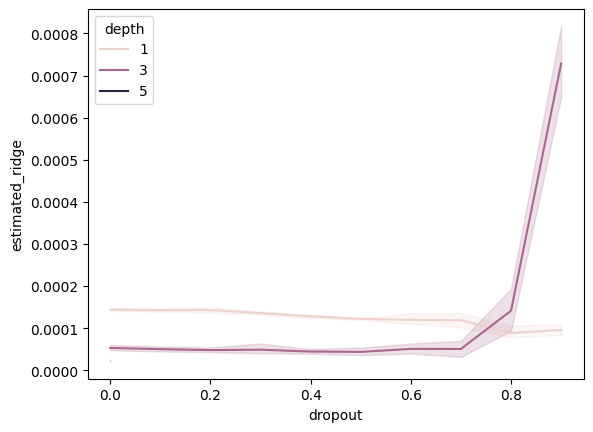

In [9]:
# Seaborn faceted plot of estimated_ridge as a function of dropout, facets covering different depths
import seaborn as sns
sns.lineplot(data=df_summary, x="dropout", y="estimated_ridge", hue="depth")


## Re-fit bias models

In [ ]:
import pandas as pd
from core.estimators import BiasWithCrossEntropy

rows = []
for run in runs:
    try:
        bias_value = fit_bias_for_run(run)
        rows.append({"run_id": run.id, "seed": run.config["seed"], "dropout": run.config["dropout"], "bias": bias_value})
    except Exception as exc:
        print(f"Skipping {run.name}: {exc.__class__.__name__}: {exc}")

df = pd.DataFrame(rows)
df.head()

{'lr': 0.005, 'seed': 42, 'depth': 5, 'width': 256, 'epochs': 500, 'bias_lr': 0.05, 'dropout': 0, 'momentum': 0.9, 'batchnorm': False, 'input_dim': 784, 'batch_size': 256, 'l2_penalty': 0, 'optimizer_cls': 'Adam', 'num_data_workers': 4, 'grad_match_loss_fn': 'mse_loss'}


wandb:   1 of 1 files downloaded.  
/home/jrudoler/inductive-bias/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jrudoler/inductive-bias/.venv/lib/python3.12/s ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
100%|██████████| 9.91M/9.91M [00:01<00:00, 6.63MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 6.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 23.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 28.1MB/s]
/home/jrudoler/inductive-bias/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You pass

Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Skipping stellar-sweep-202: NameError: name 'exit' is not defined
{'lr': 0.005, 'seed': 123, 'depth': 5, 'width': 256, 'epochs': 500, 'bias_lr': 0.05, 'dropout': 0, 'momentum': 0.9, 'batchnorm': False, 'input_dim': 784, 'batch_size': 256, 'l2_penalty': 0, 'optimizer_cls': 'Adam', 'num_data_workers': 4, 'grad_match_loss_fn': 'mse_loss'}


wandb:   1 of 1 files downloaded.  
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type                    | Params | Mode 
---------------------------------------------------------------------
0 | predictive_model | DeepReLULightningModule | 466 K  | eval 
1 | bias_model       | RidgeBias               | 1      | train
---------------------------------------------------------------------
466 K     Trainable params
0         Non-trainable params
466 K     Total params
1.867     Total estimated model params size (MB)
1         Modules in train mode
18        Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]